# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [11]:
import numpy as np
import seaborn as sns
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

import os

/tmp/ipykernel_2109/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

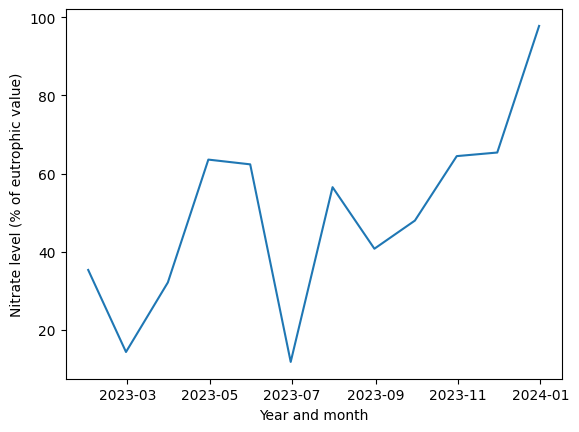

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_2109/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

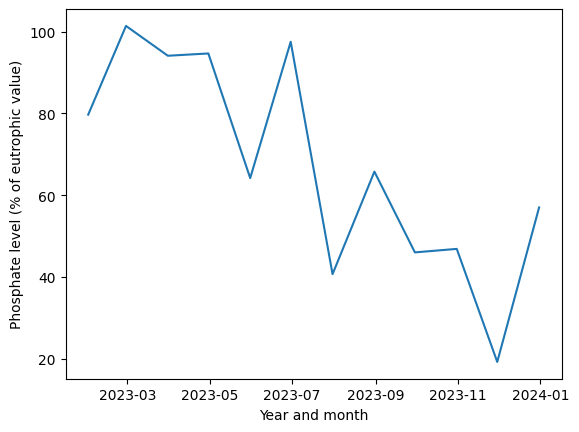

In [5]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

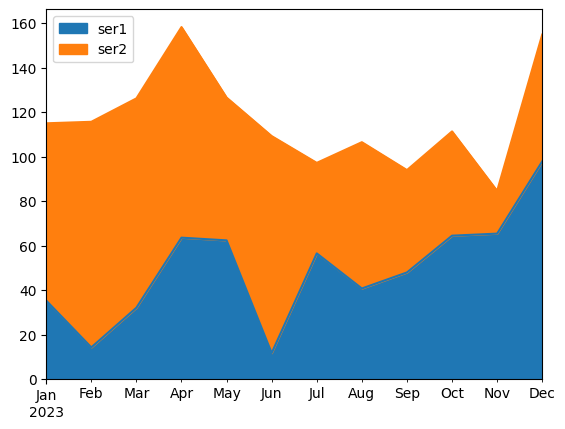

In [6]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [9]:

data_path = kagglehub.dataset_download("ericpierce/austinhousingprices")
file = os.path.join(data_path, "austinHousingData.csv")
df = pd.read_csv(file)
print("Austin Housing Data Sample:")
print(df.head())

Resuming download from 1111490560 bytes (1400245856 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/ericpierce/austinhousingprices?dataset_version_number=4 (1111490560/2511736416) bytes left.


100%|██████████| 2.34G/2.34G [00:22<00:00, 61.4MB/s]

Extracting files...


Austin Housing Data Sample:
         zpid          city          streetAddress  zipcode  \
0   111373431  pflugerville   14424 Lake Victor Dr    78660   
1   120900430  pflugerville     1104 Strickling Dr    78660   
2  2084491383  pflugerville    1408 Fort Dessau Rd    78660   
3   120901374  pflugerville     1025 Strickling Dr    78660   
4    60134862  pflugerville  15005 Donna Jane Loop    78660   

                                         description   latitude  longitude  \
0  14424 Lake Victor Dr, Pflugerville, TX 78660 i...  30.430632 -97.663078   
1  Absolutely GORGEOUS 4 Bedroom home with 2 full...  30.432673 -97.661697   
2  Under construction - estimated completion in A...  30.409748 -97.639771   
3  Absolutely darling one story home in charming ...  30.432112 -97.661659   
4  Brimming with appeal & warm livability! Sleek ...  30.437368 -97.656860   

   propertyTaxRate  garageSpaces  hasAssociation  ...  numOfMiddleSchools  \
0             1.98             2            Tru


Correlation Matrix:
                                zpid   zipcode  latitude  longitude  \
zpid                        1.000000 -0.052805 -0.055352   0.005886   
zipcode                    -0.052805  1.000000 -0.036440  -0.126135   
latitude                   -0.055352 -0.036440  1.000000   0.347597   
longitude                   0.005886 -0.126135  0.347597   1.000000   
propertyTaxRate            -0.011396 -0.172846  0.450187  -0.013746   
garageSpaces               -0.001927 -0.016600  0.019153  -0.115317   
hasAssociation              0.107227 -0.005704 -0.056766  -0.299097   
hasCooling                 -0.051843  0.075049  0.037770  -0.063926   
hasGarage                   0.021325 -0.033000  0.017619  -0.033348   
hasHeating                 -0.076695  0.051158  0.028263  -0.040448   
hasSpa                      0.003342 -0.013173  0.051272  -0.095771   
hasView                    -0.001871 -0.057906  0.036431  -0.124299   
parkingSpaces              -0.001410 -0.016687  0.018222

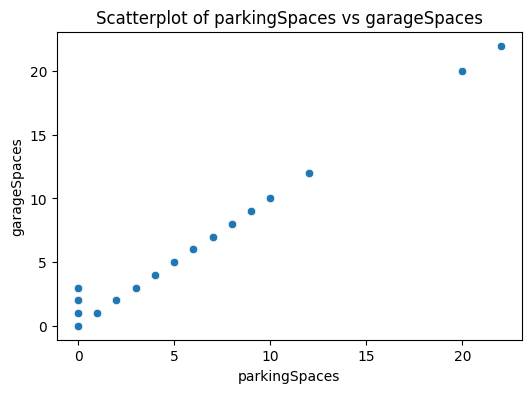

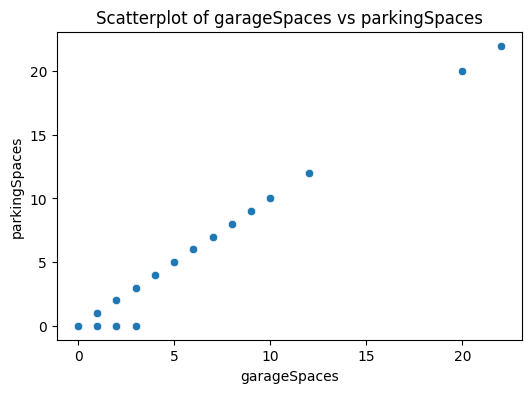

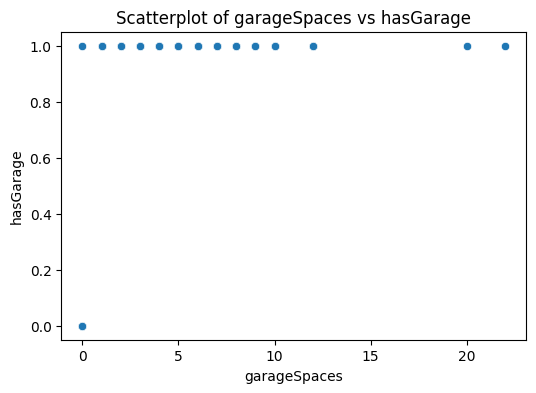

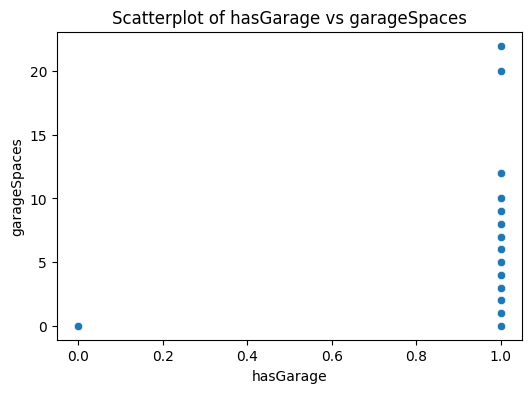

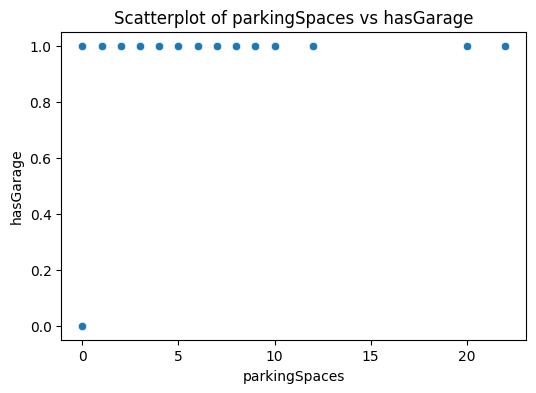

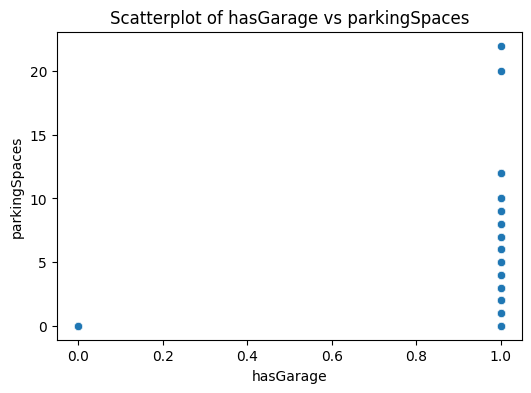

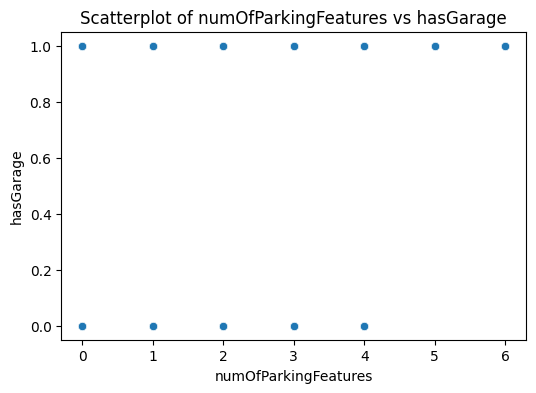

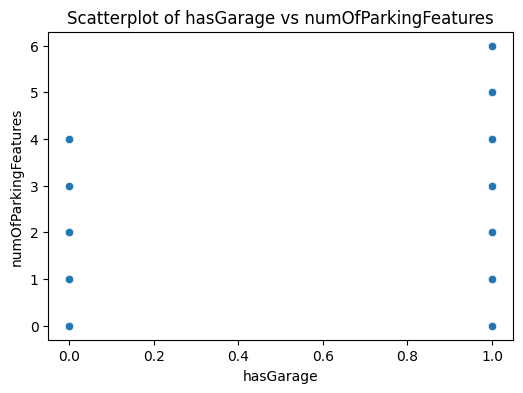

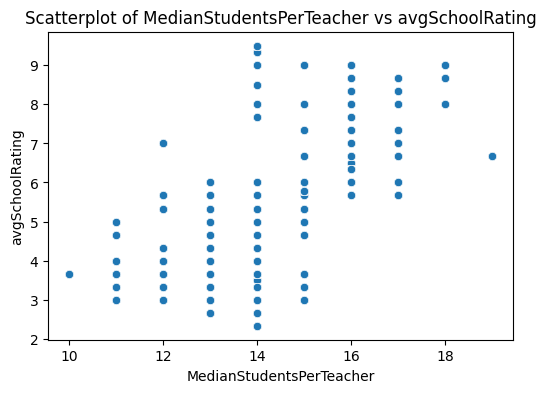

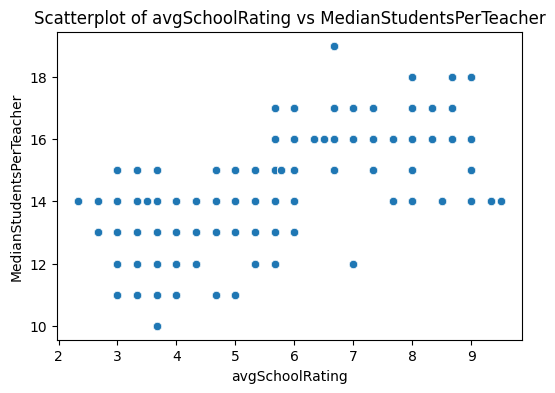

: 

In [12]:
# 1. Correlation Matrix
corr_matrix = df.corr(numeric_only=True)
print("\nCorrelation Matrix:")
print(corr_matrix)

# 2. Identifying Highly Correlated Variables
high_corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[(high_corr_pairs > 0.7) & (high_corr_pairs < 1)]
print("\nHighly Correlated Variable Pairs:")
print(high_corr_pairs)

# 3. Scatterplots for Highly Correlated Pairs
for (var1, var2) in high_corr_pairs.index:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[var1], y=df[var2])
    plt.title(f"Scatterplot of {var1} vs {var2}")
    plt.show()

# 4. Pairplot (for numerical variables)
num_cols = df.select_dtypes(include=["number"]).columns
sns.pairplot(df[num_cols])
plt.show()

# 5. Line plots for Time-based Data (if date column exists)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    
    plt.figure(figsize=(12, 5))
    df.resample("M").mean()["price"].plot(title="Average House Price Over Time")
    plt.xlabel("Year")
    plt.ylabel("Price")
    plt.show()

# 6. Identifying Outliers
outliers = {}
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

print("\nOutlier Counts per Column:")
print(outliers)

# 7. Checking for Redundant Variables (High Correlation)
redundant_features = [var1 for var1, var2 in high_corr_pairs.index]
print("\nPotential Redundant Variables:", redundant_features)

# 8. Checking for Confounding Variables
# Example: Is the relationship between 'sqft_living' and 'price' confounded by 'number of bedrooms'?
sns.lmplot(data=df, x="sqft_living", y="price", hue="bedrooms", fit_reg=True)
plt.title("Effect of Sqft Living on Price (Colored by Bedrooms)")
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.